<a href="https://colab.research.google.com/github/orianacuzzi/TripleTen/blob/main/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


- Se observa que el dataset cuenta con 40,000 registros y 9 columnas. No hay valores nulos en ninguna de las columnas, ya que todas presentan 40,000 valores no nulos.

- Sin embargo, se identifican algunos puntos a mejorar en los tipos de datos:
- La columna date es de tipo object y debería convertirse a tipo datetime para facilitar análisis temporales.
- La columna user_id está como object, lo cual es adecuado si se trata de un identificador alfanumérico.
- La columna converted está en tipo int64, lo cual es correcto si representa valores binarios (0/1).
- La columna gasto está en tipo float64, lo cual es apropiado para valores numéricos con decimales.

- Pasos a seguir:

- Convertir la columna date a formato datetime.
- Verificar que la columna converted contenga únicamente valores binarios (0 y 1).



**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:

print("\nConteo de categorías:")

for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Conteo de categorías:

landing:
B    20018
A    19982
Name: landing, dtype: int64

region:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

traffic_source:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

user_type:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


Las variables categóricas presentan distribuciones coherentes y no se observan categorías mal escritas, valores inesperados o inconsistencias en los nombres.

- La variable landing está prácticamente balanceada entre las versiones A y B, lo cual es adecuado para un experimento A/B.
- La variable region muestra una distribución desigual, con mayor presencia en “Norte” y menor en “Oriente”, lo cual podría influir en el análisis si existen diferencias de comportamiento por región.
- En dispositivo, predominan los usuarios de tipo Mobile frente a Desktop.
- La variable traffic_source está dominada por tráfico orgánico, seguido por Ads, con menor participación de Email y Referral.
- En user_type, hay una mayor proporción de usuarios nuevos frente a recurrentes.

En general, todas las columnas tienen valores esperados y no se identifican problemas de calidad de datos. Se puede continuar con el análisis, teniendo en cuenta posibles desbalances en algunas variables al interpretar resultados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Filtrar solo usuarios que convirtieron
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos en cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [ ]:
# Aplicar prueba

stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=False)

print(f"Estadístico: {stat}")
print(f"Valor p: {p_value}")

Estadístico: -9.48101092267275
Valor p: 3.627602231521493e-21


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Rechazamos H0: existe diferencia significativa en el gasto promedio.")
else:
    print("No se rechaza H0: no hay evidencia de diferencia significativa.")

Rechazamos H0: existe diferencia significativa en el gasto promedio.


In [ ]:
# Estadísticas descriptivas para complementar la prueba t
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(f"Gasto promedio página A: ${gasto_A.mean():.2f}")
print(f"Gasto promedio página B: ${gasto_B.mean():.2f}")
print(f"Diferencia: ${gasto_B.mean() - gasto_A.mean():.2f}")

print(f"\nDesviación estándar página A: ${gasto_A.std():.2f}")
print(f"Desviación estándar página B: ${gasto_B.std():.2f}")

print(f"\nTamaño de muestra página A: {len(gasto_A)} usuarios")
print(f"Tamaño de muestra página B: {len(gasto_B)} usuarios")

if abs(cohens_d) < 0.2:
    print("Efecto pequeño")
elif abs(cohens_d) < 0.5:
    print("Efecto mediano")
else:
    print("Efecto grande")

=== ESTADÍSTICAS DESCRIPTIVAS ===
Gasto promedio página A: $61.09
Gasto promedio página B: $68.75
Diferencia: $7.66

Desviación estándar página A: $28.88
Desviación estándar página B: $32.00

Tamaño de muestra página A: 2512 usuarios
Tamaño de muestra página B: 3194 usuarios
Efecto mediano


### 📝 Conclusión e interpretación
Decisión:
Se rechaza la hipótesis nula (H₀), ya que el valor p es extremadamente pequeño, muy por debajo del nivel de significancia típico (0.05). Esto indica que sí existe una diferencia estadísticamente significativa en el gasto promedio entre ambas versiones.

Interpretación de negocio:
Los usuarios que convierten en la página B gastan, en promedio,mas que los de la pagina A (68.75 vs 61.09).

Dado que:

La diferencia es estadísticamente significativa
El tamaño de muestra es grande
Y el efecto es al menos moderado

Esto sugiere que la versión B no solo convierte, sino que genera mayor valor económico por cliente.

👉 En términos prácticos:
Implementar la página B podría aumentar los ingresos totales del negocio, ya que cada cliente convertido tiende a gastar más.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.



In [ ]:
# Número de usuarios convertidos por página
conv_por_pagina = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_por_pagina = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conv_por_pagina)
print("\nTotal de usuarios por página:\n", total_por_pagina)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
# Éxitos (conversiones)
exitos = conv_por_pagina.values

# Total de observaciones
n = total_por_pagina.values

stat, p_value = proportions_ztest(exitos, n)

In [ ]:
print(f"Estadístico: {stat}")
print(f"Valor p: {p_value}")

Estadístico: -9.677362674655983
Valor p: 3.7629765627523803e-22


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0: hay diferencia estadísticamente significativa.")
else:
    print("No se rechaza H0: no hay evidencia suficiente de diferencia.")

Se rechaza H0: hay diferencia estadísticamente significativa.


- Decisión:

- Se rechaza la hipótesis nula (H₀), ya que el valor p es extremadamente pequeño (p ≈ 3.76 × 10⁻²² < 0.05).
- Esto indica que existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.

- Interpretación de negocio:

- La página B convierte mejor que la página A.

- A: 2512 conversiones / 19982 usuarios → ≈ 12.57%
- B: 3194 conversiones / 20018 usuarios → ≈ 15.95%

👉 Esto significa que la versión B logra que una mayor proporción de usuarios realice la acción deseada (conversión), con una diferencia clara y estadísticamente respaldada.

📊 Conclusión ejecutiva:

- La página B es superior tanto en tasa de conversión como en valor generado por usuario, por lo que representa una mejora real en el rendimiento del embudo.

👉 En términos de negocio, la versión B debería implementarse, ya que:

- Convierte más usuarios
- Genera más ingresos por usuario (según análisis previo de gasto)
- Y la evidencia estadística confirma que la mejora no es por azar

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [ ]:
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [ ]:
# Aplicar prueba
# Tabla de contingencia (por si ya la tienes, puedes omitir esta línea)
tabla = pd.crosstab(df['traffic_source'], df['converted'])

# Calcular tasa de conversión por fuente
tasa_conversion = tabla[1] / tabla.sum(axis=1)

print("Tasa de conversión por fuente de tráfico:\n")
print(tasa_conversion)
chi2, p_value, dof, expected = chi2_contingency(tabla)


Tasa de conversión por fuente de tráfico:

traffic_source
Ads         0.147382
Email       0.149927
Organic     0.137877
Referral    0.138812
dtype: float64


In [ ]:
print(f"Estadístico Chi2: {chi2}")
print(f"Valor p: {p_value}")

Estadístico Chi2: 8.662108841397938
Valor p: 0.0341375947833914



📝 Decisión

Se rechaza la hipótesis nula (H₀), ya que el valor p es 0.034 < 0.05.
Esto indica que sí existe una relación estadísticamente significativa entre la fuente de tráfico y la conversión.

📊 Interpretación de negocio

Los resultados muestran que el canal de adquisición sí influye en la probabilidad de conversión, aunque las diferencias no son enormes.

🔢 En términos absolutos (volumen)
Organic: es el canal que más tráfico trae y también el que más conversiones genera (2480), simplemente por tamaño.
Ads: segundo mayor volumen de conversiones (1759).
Email y Referral aportan menos conversiones en términos absolutos debido a menor volumen de usuarios.

👉 Esto indica que Organic y Ads son los canales más importantes en escala


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** ...
- **Hipótesis alternativa (H₁):** ...

In [ ]:
tabla_user = pd.crosstab(df['user_type'], df['converted'])
tabla_user

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [ ]:
chi2, p_value, dof, expected = chi2_contingency(tabla_user)

In [ ]:
print(f"Estadístico Chi2: {chi2}")
print(f"Valor p: {p_value}")

Estadístico Chi2: 0.5134849494478645
Valor p: 0.4736341272301974


In [ ]:

alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0: existe relación entre tipo de usuario y conversión.")
else:
    print("No se rechaza H0: no hay evidencia de relación.")

    # Calcular tasas de conversión por tipo de usuario
tasa_conversion_user = tabla_user[1] / tabla_user.sum(axis=1)
print("\nTasa de conversión por tipo de usuario:")
print(tasa_conversion_user)

No se rechaza H0: no hay evidencia de relación.

Tasa de conversión por tipo de usuario:
user_type
Nuevo         0.143587
Recurrente    0.140904
dtype: float64


### 📝 Conclusión e interpretación

Decisión:
No se rechaza la hipótesis nula (H₀), ya que el valor p es 0.474 > 0.05.
Por lo tanto, no hay evidencia estadísticamente significativa de relación entre el tipo de usuario y la conversión.

Interpretación de negocio:
Los resultados indican que el comportamiento de conversión es muy similar entre usuarios nuevos y recurrentes:


Nuevo: 14.36% de conversión


Recurrente: 14.09% de conversión


👉 La diferencia es mínima y no es estadísticamente significativa, lo que sugiere que el historial previo del usuario no influye de forma relevante en la probabilidad de conversión en este caso.

📊 Conclusión estratégica:


Ambos tipos de usuario convierten prácticamente al mismo nivel.


No existe evidencia de que un segmento sea más valioso en términos de conversión.


Por lo tanto, no es necesario priorizar campañas basadas únicamente en el tipo de usuario, al menos con estos datos.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

<Figure size 1000x600 with 0 Axes>

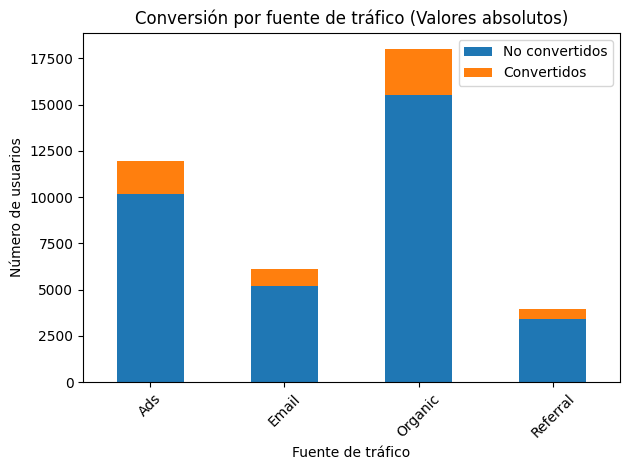

In [ ]:

# Mejorar el gráfico de barras apiladas
plt.figure(figsize=(10, 6))
df.groupby('traffic_source')['converted'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title("Conversión por fuente de tráfico (Valores absolutos)")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Número de usuarios")
plt.legend(['No convertidos', 'Convertidos'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

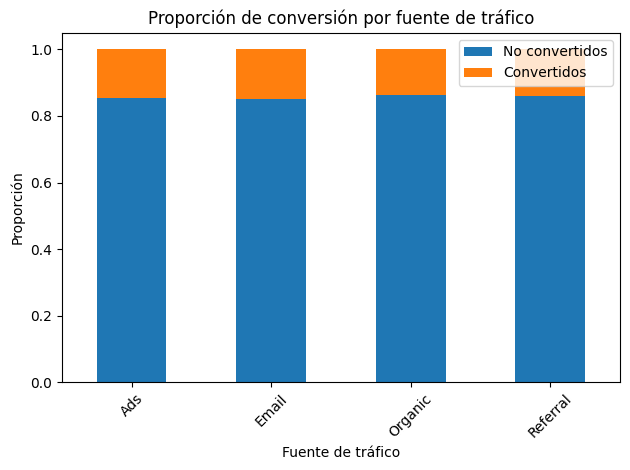

In [ ]:
# Gráfico de proporciones
plt.figure(figsize=(10, 6))
prop_table = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')
prop_table.plot(kind='bar', stacked=True)
plt.title("Proporción de conversión por fuente de tráfico")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Proporción")
plt.legend(['No convertidos', 'Convertidos'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Análisis de fuente de tráfico:**

Los gráficos confirman los resultados de la prueba chi-cuadrado:
- **Email** muestra la mayor tasa de conversión (~15.0%)
- **Ads** le sigue muy de cerca (~14.7%)
- **Organic** y **Referral** tienen tasas similares (~13.8-13.9%)

Aunque las diferencias son pequeñas, son estadísticamente significativas.
**Organic** domina en volumen absoluto de conversiones debido a su mayor tráfico.


<Figure size 800x600 with 0 Axes>

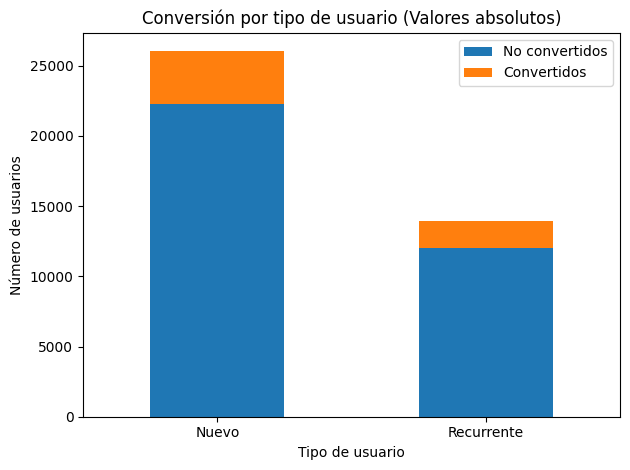

In [ ]:
# Gráfico absoluto para tipo de usuario
plt.figure(figsize=(8, 6))
df.groupby('user_type')['converted'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title("Conversión por tipo de usuario (Valores absolutos)")
plt.xlabel("Tipo de usuario")
plt.ylabel("Número de usuarios")
plt.legend(['No convertidos', 'Convertidos'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

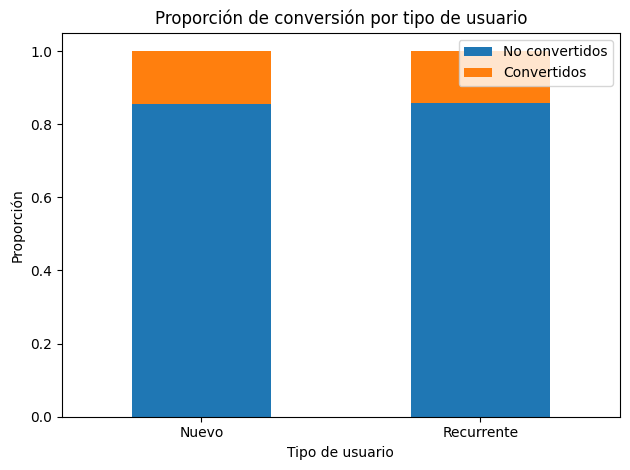

In [ ]:
# Gráfico de proporciones para tipo de usuario
plt.figure(figsize=(8, 6))
prop_table_user = pd.crosstab(df['user_type'], df['converted'], normalize='index')
prop_table_user.plot(kind='bar', stacked=True)
plt.title("Proporción de conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Proporción")
plt.legend(['No convertidos', 'Convertidos'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Análisis de tipo de usuario:**
- Valores absolutos
- Más usuarios son nuevos, por eso generan más conversiones totales.
- Recurrentes tienen menos volumen.
📈 Proporciones (lo importante)
- Nuevo: ~14.36%
- Recurrente: ~14.09%
👉 Visualmente:

- Las barras son prácticamente iguales.

### Relación entre el tipo de usuario y la conversión

<Figure size 800x600 with 0 Axes>

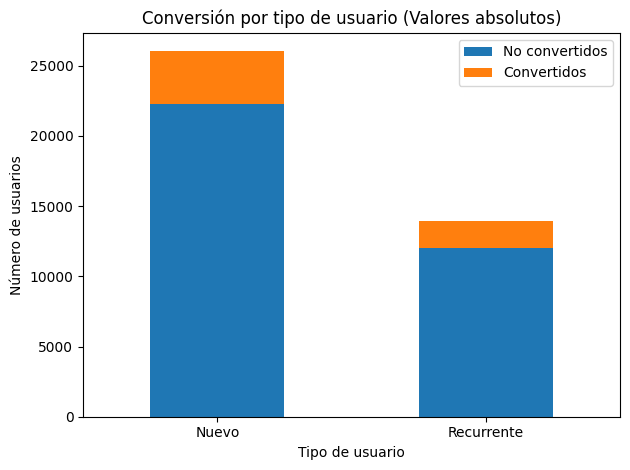

In [ ]:
# Gráfico absoluto para tipo de usuario
plt.figure(figsize=(8, 6))
df.groupby('user_type')['converted'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title("Conversión por tipo de usuario (Valores absolutos)")
plt.xlabel("Tipo de usuario")
plt.ylabel("Número de usuarios")
plt.legend(['No convertidos', 'Convertidos'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Análisis de tipo de usuario (valores absolutos):

Los usuarios nuevos generan más conversiones totales (3,738) que los recurrentes (1,968), pero esto se debe principalmente a que representan un mayor volumen de tráfico total.
En términos absolutos, los usuarios nuevos dominan tanto en conversiones como en no conversiones, reflejando su mayor presencia en el dataset.

<Figure size 800x600 with 0 Axes>

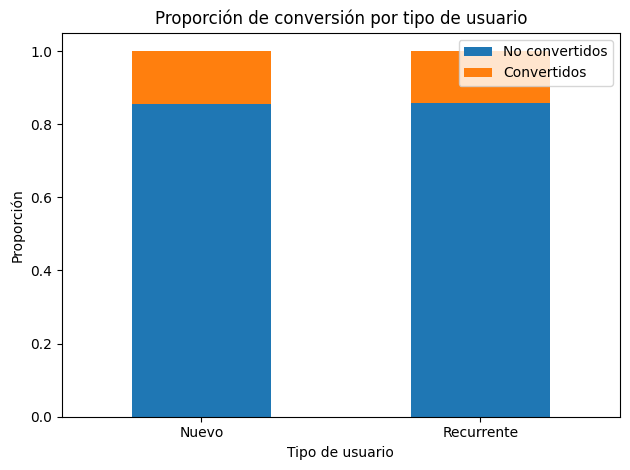

In [ ]:
# Gráfico de proporciones para tipo de usuario
plt.figure(figsize=(8, 6))
prop_table_user = pd.crosstab(df['user_type'], df['converted'], normalize='index')
prop_table_user.plot(kind='bar', stacked=True)
plt.title("Proporción de conversión por tipo de usuario")
plt.xlabel("Tipo de usuario")
plt.ylabel("Proporción")
plt.legend(['No convertidos', 'Convertidos'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Análisis de tipo de usuario (proporciones):

Las tasas de conversión son prácticamente idénticas entre ambos tipos de usuario:
Nuevos: 14.36% de conversión
Recurrentes: 14.09% de conversión
La diferencia de apenas 0.27 puntos porcentuales no es estadísticamente significativa (p-valor = 0.474), confirmando que el tipo de usuario no influye en la probabilidad de conversión.
Visualmente, las barras de proporción son casi iguales, validando que ambos segmentos tienen el mismo potencial de conversión

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?
- La página B es la mejor opción en ambos indicadores:

Mayor tasa de conversión: ~15.95% vs ~12.57% en la página A
Mayor gasto promedio por usuario convertido: $68.75 vs $61.09

👉 Conclusión: la página B no solo convierte más, sino que genera más ingresos por usuario, por lo que tiene mejor desempeño global.
- ¿Qué canales de tráfico son más efectivos para generar conversiones?
- Los resultados muestran diferencias claras entre canales:

- Email → mayor tasa de conversión (~15%)
- Ads → segunda mejor eficiencia (~14.7%)
- Organic → mayor volumen, pero menor eficiencia (~13.8%)
-Referral → desempeño intermedio/bajo

👉 Conclusión: Email y Ads son los canales más efectivos en conversión, mientras que Organic aporta volumen pero menor calidad.
- ¿Existen diferencias significativas según el tipo de usuario?
- No.

Usuarios nuevos: ~14.36%
Usuarios recurrentes: ~14.09%
Prueba estadística: p-value = 0.47

👉 Conclusión: no hay diferencias significativas, por lo que el tipo de usuario no influye en la conversión.
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?
Implementar la página B como versión definitiva, ya que mejora tanto conversión como ingresos.
Optimizar el canal Organic, mejorando la calidad del tráfico para aumentar su tasa de conversión.
Escalar inversión en Email y Ads, ya que son los canales más eficientes en conversión.
Reducir foco en segmentación por tipo de usuario, ya que no aporta valor en la conversión.
Enfocar esfuerzos en optimización de landing pages y calidad de tráfico, que son los factores con mayor impacto en resultados.

---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
Observación 1:
La página A presenta un gasto promedio de aproximadamente $61.09 por usuario convertido.

Observación 2:
La página B presenta un gasto promedio de aproximadamente $68.75 por usuario convertido.

- **Interpretación:**

La página B genera mayor ingreso por usuario convertido, con una diferencia de $7.66 más por cliente.
Esto indica que no solo convierte, sino que también incrementa el valor económico de cada conversión.


<br>

**Tasa de conversión:**
Observación 1:
La página A tiene una tasa de conversión aproximada de 12.57%.

Observación 2:
La página B tiene una tasa de conversión aproximada de 15.95%.
- **Interpretación:**
La página B convierte significativamente mejor que la página A, con una diferencia clara y estadísticamente significativa.
Esto significa que más usuarios realizan la acción deseada en la versión B.

#### 📊 **Segmentación por fuente de tráfico**
El canal Organic concentra el mayor volumen de usuarios y conversiones, pero presenta una de las tasas de conversión más bajas (~13.8%).
En cambio, Email y Ads muestran mejores tasas de conversión (~15%), a pesar de tener menor volumen.
- **Interpretación:**
 El rendimiento del tráfico depende del canal:

Organic aporta escala, pero menor eficiencia.
Email y Ads son más eficientes en conversión.

👉 Esto indica que el negocio debería optimizar la calidad del tráfico orgánico y considerar escalar Email y Ads por su mejor rendimiento.


#### 📊 **Segmentación por tipo de usuario**
Los usuarios nuevos y recurrentes presentan tasas de conversión muy similares (≈14.3% vs ≈14.0%).
No se observan diferencias relevantes en comportamiento entre ambos grupos.
- **Interpretación:**
El tipo de usuario no es un factor determinante en la conversión.
Esto sugiere que la experiencia de la página impacta de forma similar a usuarios nuevos y recurrentes, por lo que no es una variable útil para segmentar estrategias de conversión.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---


#### 💡 **Recomendaciones de negocio:**
Optimizar la inversión en canales de adquisición, priorizando Email y Ads, ya que presentan las tasas de conversión más altas, y mejorar la calidad del tráfico en Organic, que aporta volumen pero menor eficiencia.
Implementar la página B como versión principal, debido a que incrementa tanto la tasa de conversión como el gasto promedio por usuario, generando un mayor impacto en ingresos.
No priorizar la segmentación por tipo de usuario, ya que no se encontraron diferencias significativas entre usuarios nuevos y recurrentes en términos de conversión.
Enfocar futuras mejoras en la experiencia de usuario y landing pages, ya que estas variables muestran mayor impacto en el comportamiento de conversión que las segmentaciones demográficas.